# Importaciones Necesarias:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report
from sklearn.metrics import roc_curve,roc_auc_score,precision_recall_curve,auc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif


# Lectura de los datos

In [2]:
datos = pd.read_csv('student_dropout_dataset_v3.csv')
drop_cols = ["Student_ID", "Dropout"]

X = datos.drop(columns=drop_cols)
y = datos['Dropout']

X['Semester'] = X['Semester'].str[-1].astype(int)

In [3]:
num_cols = ["Age", "Family_Income", "Study_Hours_per_Day", "Attendance_Rate", 
            "Assignment_Delay_Days", "Travel_Time_Minutes", "Stress_Index", 
            "GPA", "Semester_GPA", "CGPA", "Semester"]

cat_cols = ["Department", "Gender", "Internet_Access",
            "Parental_Education", "Part_Time_Job", "Scholarship"]

# Resumen de los datos

In [4]:
resumenEntrada = X.describe()
resumenSalida = y.describe()
print(resumenEntrada)
print(resumenSalida)

               Age  Family_Income  Study_Hours_per_Day  Attendance_Rate  \
count  10000.00000    9500.000000          9500.000000      10000.00000   
mean      21.02606   38377.247474             4.014592         81.73683   
std        2.13981   20496.232179             1.295450          8.22093   
min       17.00000   25000.000000             0.500000         38.20000   
25%       19.50000   25000.000000             3.160000         76.40000   
50%       21.00000   29740.500000             4.000000         81.80000   
75%       22.50000   44520.000000             4.870000         87.30000   
max       29.60000  316601.000000             8.980000        100.00000   

       Assignment_Delay_Days  Travel_Time_Minutes  Stress_Index           GPA  \
count           10000.000000          10000.00000   9500.000000  10000.000000   
mean                1.799700             30.17926      5.507147      2.308440   
std                 1.344307             11.91887      1.765951      1.061717   


Variables con valores faltantes:

In [5]:
X.isnull().sum()

Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
dtype: int64

# Gráficas para mostrar datos:

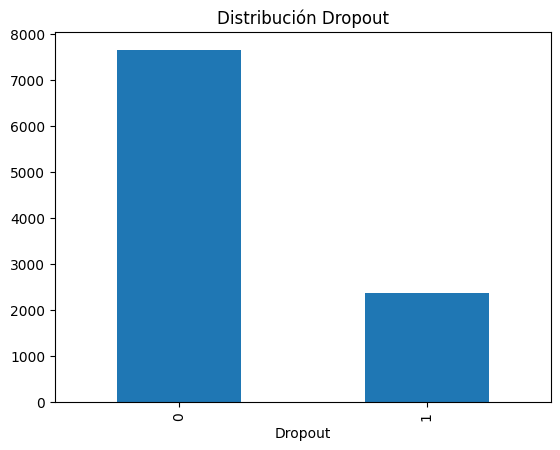

In [6]:
# Gráfica que muestra la distribución de dropout

y.value_counts().plot(kind="bar")
plt.title("Distribución Dropout")
plt.show()

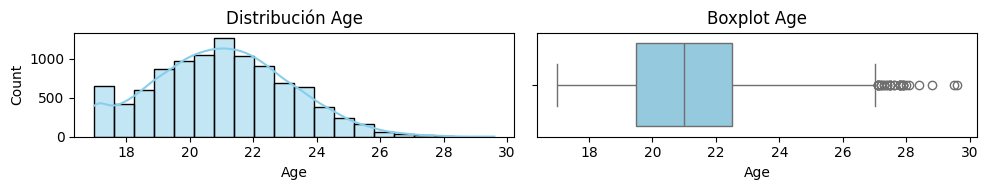

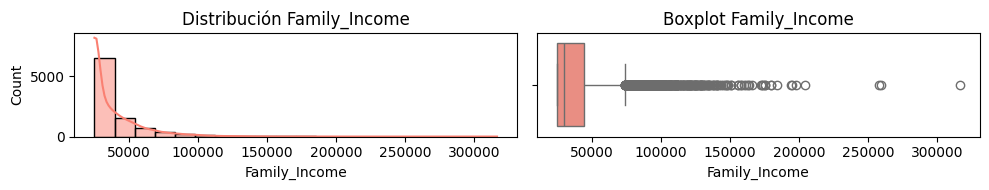

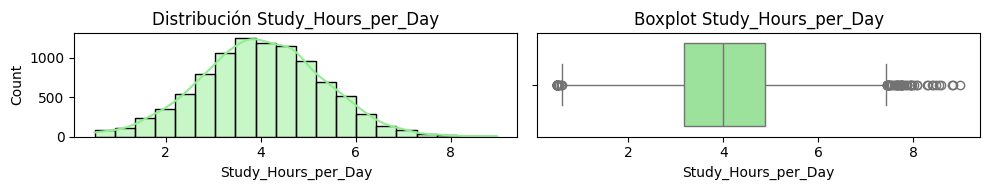

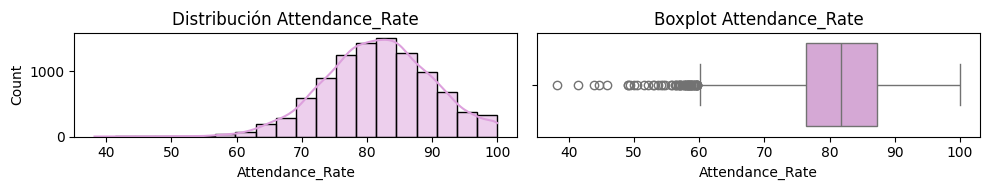

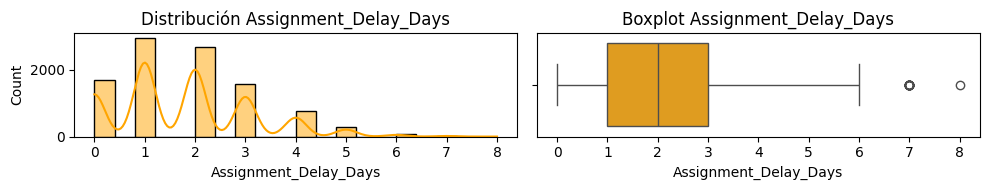

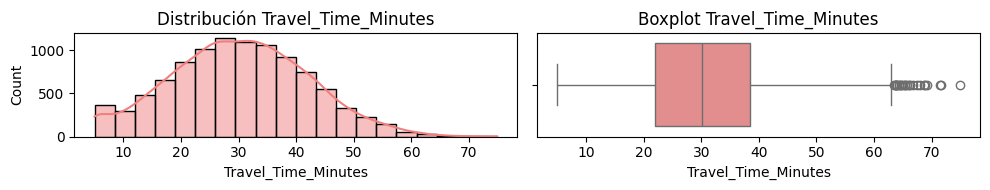

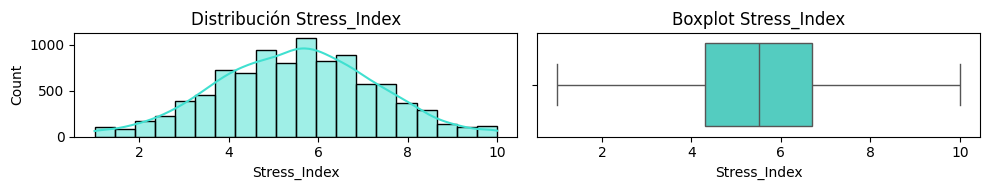

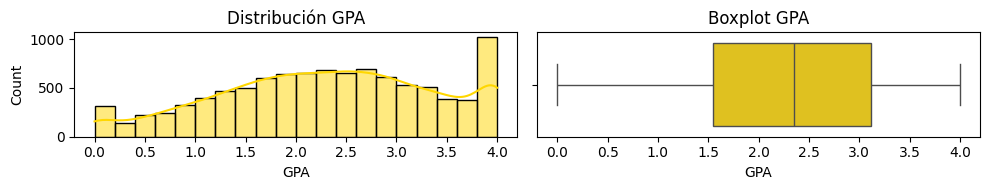

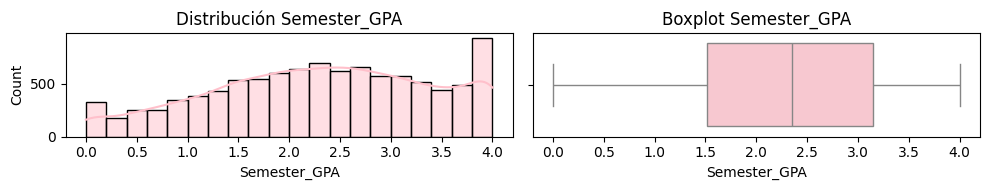

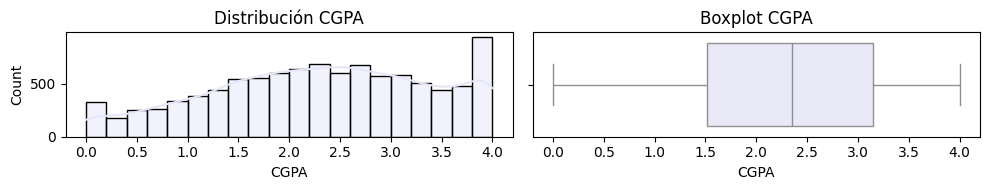

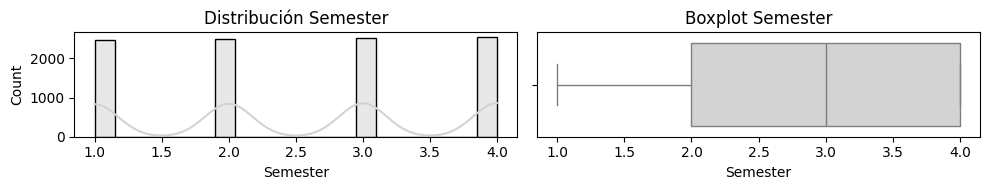

In [7]:
num_cols = ["Age", "Family_Income", "Study_Hours_per_Day", "Attendance_Rate", 
            "Assignment_Delay_Days", "Travel_Time_Minutes", "Stress_Index", 
            "GPA", "Semester_GPA", "CGPA", "Semester"]

colors = ["skyblue", "salmon", "lightgreen", "plum", "orange", 
          "lightcoral", "turquoise", "gold", "pink", "lavender", "lightgray"]

for col, color in zip(num_cols, colors):
    fig, axes = plt.subplots(1, 2, figsize=(10, 2))
    
    sns.histplot(data=X, x=col, bins=20, kde=True, color=color, ax=axes[0])
    axes[0].set_title(f"Distribución {col}")
    
    sns.boxplot(data=X, x=col, color=color, ax=axes[1])
    axes[1].set_title(f"Boxplot {col}")
    
    plt.tight_layout()
    plt.show()

# Distribución de clases para cada variable:

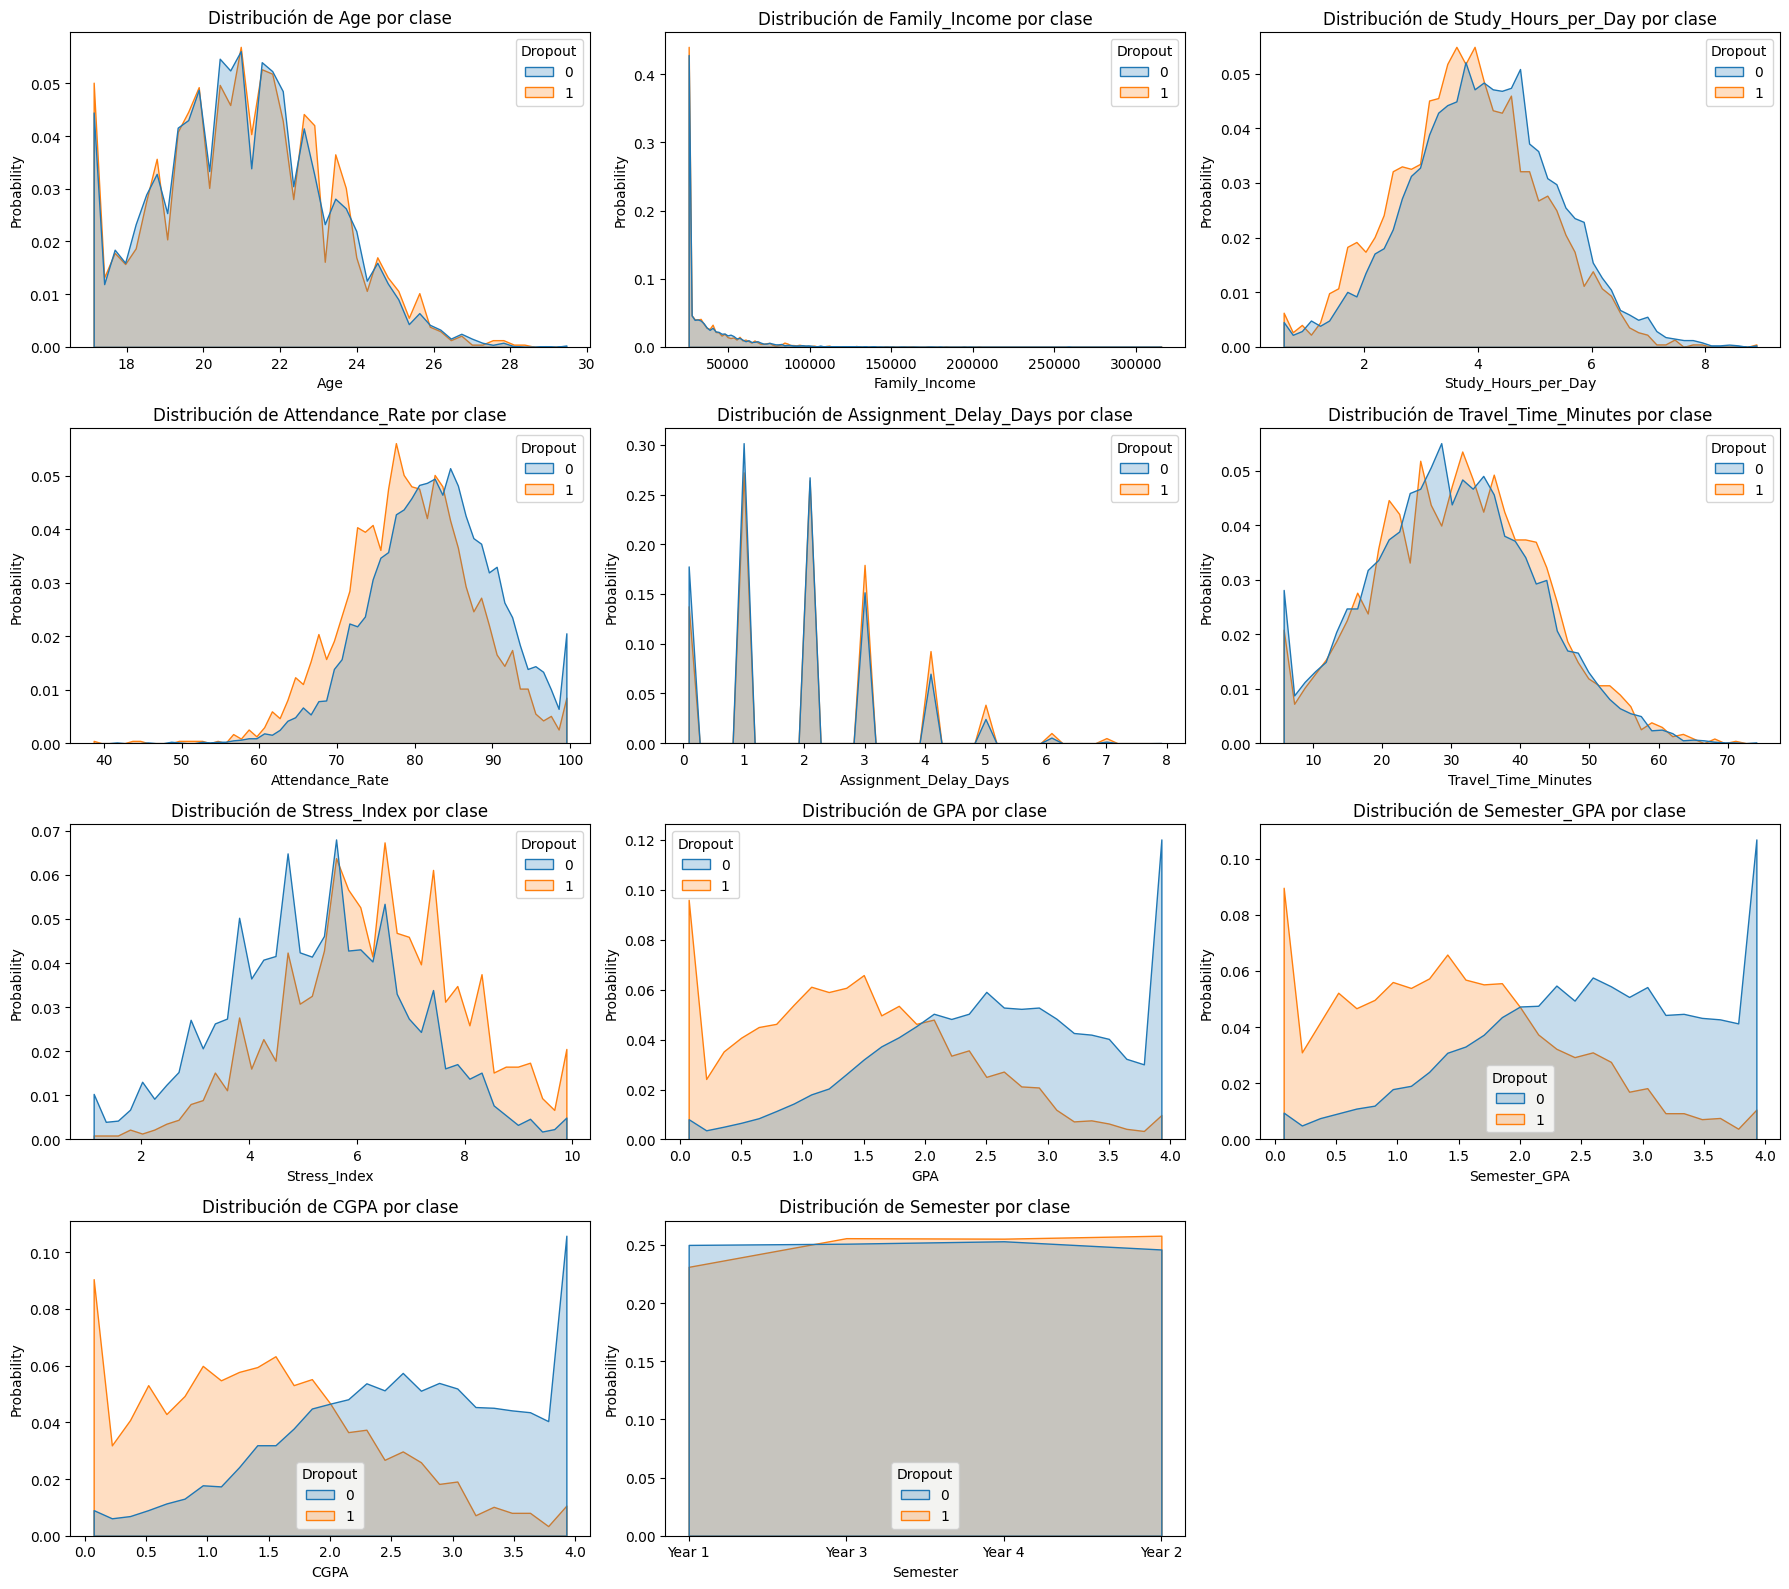

In [8]:
n_cols = 3
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, columna in enumerate(num_cols):
    sns.histplot(
        data=datos,
        x=columna,
        hue="Dropout",
        element='poly',
        stat='probability',
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribución de {columna} por clase")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Distribución de variables categoricas con Dropout

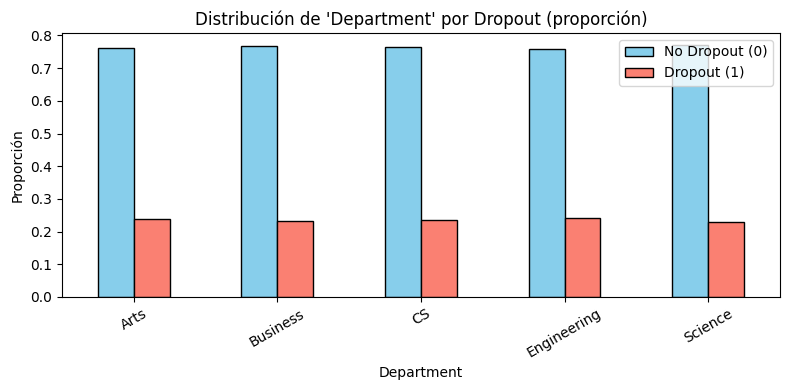

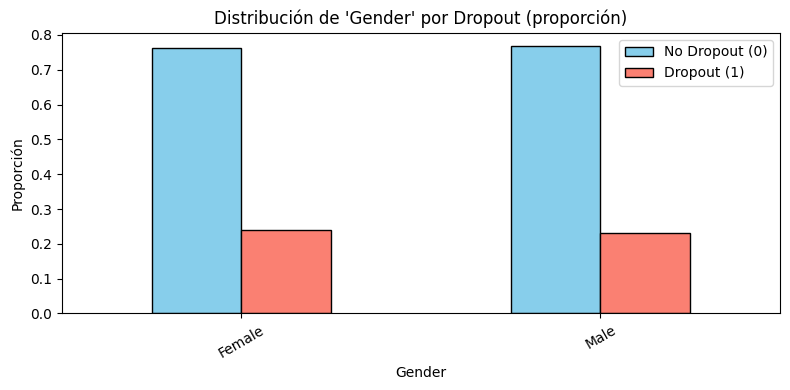

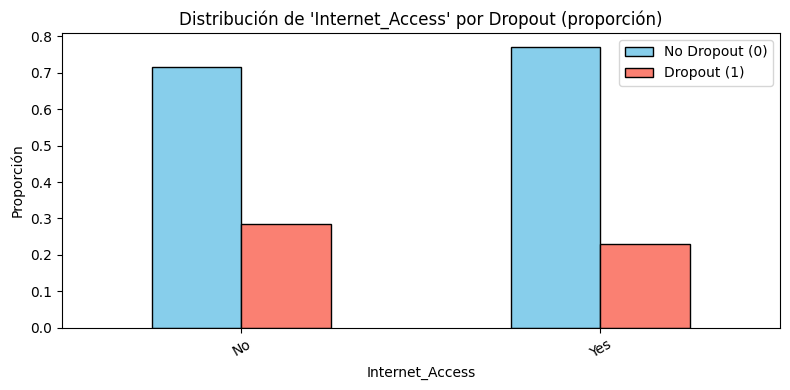

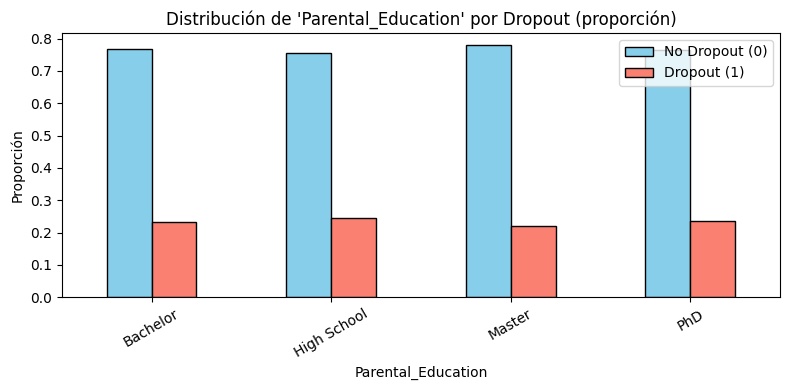

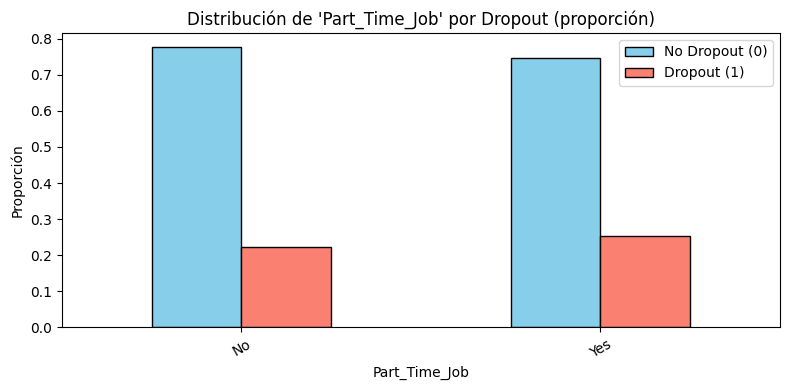

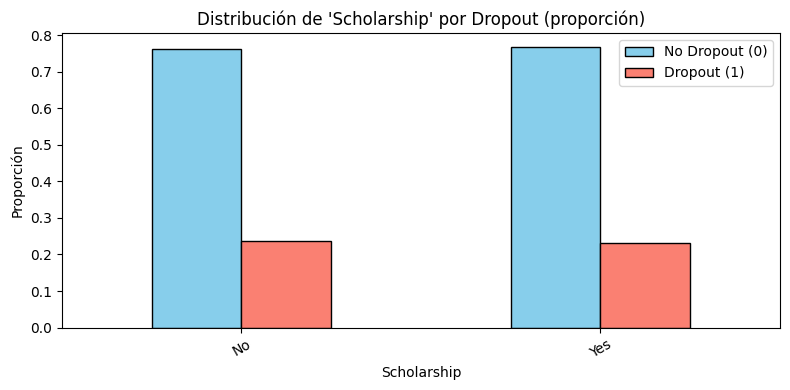

In [9]:

cat_cols_plot = ["Department", "Gender", "Internet_Access","Parental_Education", "Part_Time_Job", "Scholarship"]

for col in cat_cols_plot:
    fig, ax = plt.subplots(figsize=(8, 4))

    tabla = datos.groupby([col, "Dropout"]).size().unstack(fill_value=0)
    tabla_norm = tabla.div(tabla.sum(axis=1), axis=0)
    tabla_norm.plot(kind="bar", ax=ax, color=["skyblue", "salmon"], edgecolor="black")
    ax.set_title(f"Distribución de '{col}' por Dropout (proporción)")
    ax.set_xlabel(col)
    ax.set_ylabel("Proporción")
    ax.legend(["No Dropout (0)", "Dropout (1)"])
    ax.tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.show()

# Correlación entre variables numéricas y la variable de salida:

Dropout                  1.000000
Stress_Index             0.255648
Assignment_Delay_Days    0.082327
Travel_Time_Minutes      0.028080
Semester                 0.010658
Age                      0.007585
Family_Income           -0.011123
Study_Hours_per_Day     -0.089376
Attendance_Rate         -0.163539
CGPA                    -0.444807
Semester_GPA            -0.445396
GPA                     -0.460352
Name: Dropout, dtype: float64


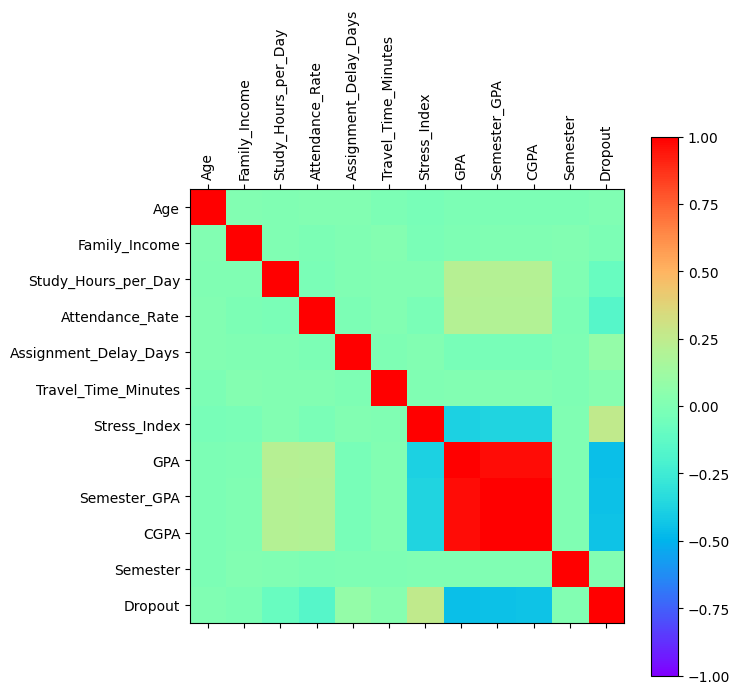

In [10]:
X_num = X[num_cols].copy()
X_num["Dropout"] = y
# Cálculo de la matriz de correlaciones con la función corr de pandas
correlaciones = X_num.corr()
print(correlaciones["Dropout"].sort_values(ascending=False))

# Mostramos la matriz de correlaciones especificando el rango de los valores [-1, 1]
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
cax = ax.matshow(correlaciones, vmin=-1, vmax=1, cmap=plt.cm.rainbow)
fig.colorbar(cax)
ticks = np.arange(0,len(X_num.columns),1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
# Añadimos los nombres de las variables en la figura
names = X_num.columns
ax.set_xticklabels(names, rotation='vertical')
ax.set_yticklabels(names)
plt.show()

# Correlación entre cada variable categórica y la variable objetivo:  
Mediante Cramer   

In [11]:

cat_cols = X.columns.difference(num_cols)

def cramers_v(X, y):
    tabla = pd.crosstab(X, y)
    chi2 = chi2_contingency(tabla)[0]      
    n = tabla.sum().sum()
    q = min(tabla.shape) - 1
    return np.sqrt(chi2 / (n * q))

for col in cat_cols:
    v = cramers_v(X[col], y)
    print(f"{col}: Cramér's V = {v:.4f}")


Department: Cramér's V = 0.0087
Gender: Cramér's V = 0.0070
Internet_Access: Cramér's V = 0.0428
Parental_Education: Cramér's V = 0.0216
Part_Time_Job: Cramér's V = 0.0365
Scholarship: Cramér's V = 0.0064


Las variables individualmente son independientes al dropout: no utiles a menos que haya una relación multivariable

# División de datos en conjuntos de entrenamiento, validación y test.  
Test es el 10% de los ejemplos, entrenamiento es 80% del resto (72%) y validación lo faltante (18%).

In [12]:

X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size = 0.10, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_resto, y_resto, test_size = 0.20, stratify=y_resto, random_state=42)


# Detección y tratamiento de outliers:

Detección de outliers con IQR y mediana

In [13]:
# Creamos la clase de detección y tratamiento de Outliers
class OutlierDetecion_treatment_IQR(TransformerMixin):

    # Constructor de la clase
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # Método fit
    def fit(self, X, y=None):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        if self.columns is None:
            # Si no se determinan variables en el constructor si tratan todas
            self.columns = X.select_dtypes(include="number").columns
        self.stats = X[self.columns].describe()
        self.median = X[self.columns].median()

        # Devolvemos el propio objeto modificado
        return self

    # Método transform
    def transform(self, X):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Creamos una copia del DataFrame X para no perder los datos originales
        Xaux = X.copy()


        # Se comprueba qué elementos están por encima y por debajo de dichos límites (máscaras de booleanos)
        Q1 = self.stats.loc['25%']   
        Q3 = self.stats.loc['75%']
        IQRs = Q3 - Q1
        limiteInf = Q1 - self.k * IQRs
        limiteSup = Q3 + self.k * IQRs  
        menores = Xaux[self.columns] < limiteInf
        mayores = Xaux[self.columns] > limiteSup

        # Se recorren las variables para detectar outliers y tratarlos (sustituir por la mediana de la variable)
        for c in self.columns:
            # obtenemos la lista de booleanos correspondientes a si los valores de los ejemplos son outliers o no para la variable c
#             indices = <RELLENAR>
            indices = np.logical_or(menores[c],mayores[c])
            # Si hay outliers
            # <RELLENAR>
            if indices.any():
                Xaux.loc[indices,c] = self.median[c]
                # Los sustituimos por la mediana
                # <RELLENAR>
        # Se devuelve el DataFrame modificado
        return Xaux
    
    # Método para asignar los valores de los híper-parámetros y que, de este modo, 
        # podamos aplicar GridSearchCV sobre un objeto de esta clase
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
    def get_params(self, deep=True):
        # Devolvemos los valores de los híper-parámetros del método de preparación de datos
        return {"k": self.k}

Detección de outliers con media y desviación (mediana)

In [14]:
# Creamos la clase de detección y tratamiento de Outliers
class OutlierDetecion_treatment_MeanStd(TransformerMixin):

    # Constructor de la clase
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # Método fit
    def fit(self, X, y=None):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        if self.columns is None:
            # Si no se determinan variables en el constructor si tratan todas
            self.columns = X.select_dtypes(include="number").columns
        self.stats = X[self.columns].describe()
        self.media = X[self.columns].mean()
        self.desviacion = X[self.columns].std()
        self.median = X[self.columns].median()
        # Devolvemos el propio objeto modificado
        return self

    # Método transform
    def transform(self, X):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Creamos una copia del DataFrame X para no perder los datos originales
        Xaux = X.copy()


        # Se comprueba qué elementos están por encima y por debajo de dichos límites (máscaras de booleanos)
        
        limiteInf = self.media - self.k * self.desviacion
        limiteSup = self.media + self.k * self.desviacion 
        menores = Xaux[self.columns] < limiteInf
        mayores = Xaux[self.columns] > limiteSup

        # Se recorren las variables para detectar outliers y tratarlos (sustituir por la mediana de la variable)
        for c in self.columns:
            # obtenemos la lista de booleanos correspondientes a si los valores de los ejemplos son outliers o no para la variable c
#             indices = <RELLENAR>
            indices = np.logical_or(menores[c],mayores[c])
            # Si hay outliers
            # <RELLENAR>
            if indices.any():
                Xaux.loc[indices,c] = self.median[c]
                # Los sustituimos por la mediana
                # <RELLENAR>
        # Se devuelve el DataFrame modificado
        return Xaux
    
    # Método para asignar los valores de los híper-parámetros y que, de este modo, 
        # podamos aplicar GridSearchCV sobre un objeto de esta clase
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
    def get_params(self, deep=True):
        # Devolvemos los valores de los híper-parámetros del método de preparación de datos
        return {"k": self.k}

Mismos Detectores de Outliers pero reemplazando por extremos:

In [15]:
class OutlierDetecion_treatment_IQR_Extremos(TransformerMixin):

    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if self.columns is None:
            # Seleccionamos solo variables numéricas
            self.columns = X.select_dtypes(include="number").columns
        
        # Calculamos estadísticos solo de las variables numéricas
        self.stats = X[self.columns].describe(percentiles=[0.25, 0.75])
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        Xaux = X.copy()

        IQRs      = self.stats.loc["75%", :] - self.stats.loc["25%", :]
        limiteInf = self.stats.loc["25%", :] - self.k * IQRs
        limiteSup = self.stats.loc["75%", :] + self.k * IQRs

        # Iteramos por las variables numéricas
        for c in self.columns:
            Xaux[c] = Xaux[c].astype(float)
            mask_low  = Xaux[c] < limiteInf[c]
            mask_high = Xaux[c] > limiteSup[c]
            if mask_low.any():
                Xaux.loc[mask_low,  c] = limiteInf[c]
            if mask_high.any():
                Xaux.loc[mask_high, c] = limiteSup[c]

        return Xaux
    
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}
    
    from sklearn.base import TransformerMixin


class OutlierDetecion_treatment_MeanStd_Extremos(TransformerMixin):
    
    # Añadimos el parámetro columns al constructor
    def __init__(self, k=2, columns=None):
        self.k = k
        self.columns = columns

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if self.columns is None:
            # Seleccionamos solo variables numéricas
            self.columns = X.select_dtypes(include="number").columns
            
        # Calculamos media y desviación SOLO de las numéricas
        self.mean_ = X[self.columns].mean()
        self.std_  = X[self.columns].std()
        return self
    
    def transform(self, X):
        Xaux = pd.DataFrame(X).copy()
        
        limiteInf = self.mean_ - self.k * self.std_
        limiteSup = self.mean_ + self.k * self.std_
        
        # Iteramos SOLO por las variables numéricas
        for c in self.columns:
            Xaux[c] = Xaux[c].astype(float)
            mask_low  = Xaux[c] < limiteInf[c]
            mask_high = Xaux[c] > limiteSup[c]
            
            if mask_low.any():
                Xaux.loc[mask_low,  c] = limiteInf[c]
            if mask_high.any():
                Xaux.loc[mask_high, c] = limiteSup[c]
        
        return Xaux
    
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}

# Nuevas Variables Numéricas

In [16]:
"""# Mide la diferencia entre el gpa acumulado y el respectivo del semestre
X['GPA_Drop'] = X['CGPA'] - X['Semester_GPA']  
# Positivo == por debajo de su media histórica

# Índice de riesgo combinado
X['Risk_Index'] = X['Stress_Index'] * X['Assignment_Delay_Days']

# Eficiencia del estudiante
X['Study_Efficiency'] = X['GPA'] / (X['Study_Hours_per_Day'] + 1)

num_cols_new = num_cols + ['GPA_Drop', 'Risk_Index', 
                            'Study_Efficiency']
# Asistencia ponderada por rendimiento
 # X['Engagement'] = X['Attendance_Rate'] * X['GPA'] (Esta no se si está muy bien , ya probaremos)"""

"# Mide la diferencia entre el gpa acumulado y el respectivo del semestre\nX['GPA_Drop'] = X['CGPA'] - X['Semester_GPA']  \n# Positivo == por debajo de su media histórica\n\n# Índice de riesgo combinado\nX['Risk_Index'] = X['Stress_Index'] * X['Assignment_Delay_Days']\n\n# Eficiencia del estudiante\nX['Study_Efficiency'] = X['GPA'] / (X['Study_Hours_per_Day'] + 1)\n\nnum_cols_new = num_cols + ['GPA_Drop', 'Risk_Index', \n                            'Study_Efficiency']\n# Asistencia ponderada por rendimiento\n # X['Engagement'] = X['Attendance_Rate'] * X['GPA'] (Esta no se si está muy bien , ya probaremos)"

# Nuevas Variables Categóricas

In [17]:
#variablesInteracciones = ['Department', 'Gender', 'Internet_Access', 'Parental_Education', 
                          #'Part_Time_Job', 'Scholarship']

#interacciones = pd.DataFrame()
#    for j in range(i+1, len(variablesInteracciones)):
   #     interacciones[variablesInteracciones[i]+"_"+variablesInteracciones[j]] = X[variablesInteracciones[i]] + "_" + X[variablesInteracciones[j]]

#X = pd.concat([X, interacciones], axis = 1)
#cat_cols_new = list(cat_cols) + list(interacciones.columns)

In [18]:
class FeatureConstruction(TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        Xaux = pd.DataFrame(X).copy()
        Xaux.columns = Xaux.columns.astype(str)  # primero normalizar nombres
        
        Xaux['GPA_Drop'] = Xaux['9'] - Xaux['8']   # CGPA - Semester_GPA
        Xaux['Risk_Index'] = Xaux['6'] * Xaux['4']   # Stress * Delay
        Xaux['Study_Efficiency'] = Xaux['7'] / (Xaux['2'] + 1)  # GPA / (Hours+1)
        return Xaux

    def get_params(self, deep=True):
        return {}



# Log Transformer

In [19]:
class LogTransformer(TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        X.columns = X.columns.astype(str)
        if self.columns is None:
            self.columns = list(X.columns)
        return self

    def transform(self, X):
        Xaux = pd.DataFrame(X).copy()
        Xaux.columns = Xaux.columns.astype(str) 
        for v in self.columns:
            Xaux[f'log_{v}'] = np.log(np.abs(Xaux[v]) + 1)
        return Xaux

    def set_params(self, **parameters):
        for p, v in parameters.items():
            setattr(self, p, v)
        return self

    def get_params(self, deep=True):
        return {"columns": self.columns}

# Selección de variables  

* Análisis de correlaciones

In [20]:
class corr_selection(TransformerMixin):

        # Constructor de la clase
        def __init__(self, umbral=0.9, verbose=False):
            # Umbral deseado para determinar variables correlacionadas
            self.umbral = umbral
            # Parámetro que determina si imprimir información del proceso o no
            self.verbose = verbose

        # Método fit
        def fit(self, X, y=None):
            # Transformamos X en DataFrame por si acaso llega en formato ndarray
            X = pd.DataFrame(X)
            # Calculamos la matriz de correlaciones con la función corr de pandas sobre el DataFrame con las variables de entrada X y la ponemos en valor absoluto
            correlaciones = X.corr().abs()
            # Seleccionamos el triángulo superior de la matriz de correlación
            upper = correlaciones.where(np.triu(np.ones(correlaciones.shape), k=1).astype('bool'))
            # Obtenemos los nombres de aquellas variables con correlación mayor al umbral deseado
            self.variables_a_eliminar = list(set([column for i,column in enumerate(upper.columns) if any(upper[column] > self.umbral)]))

             # Si queremos mostrar información se muestra el número de variables eliminadas y sus nombres
            if self.verbose:
                print('Se han eliminado {} variables, que son: {}'.format(len(self.variables_a_eliminar), self.variables_a_eliminar))
            # Devolvemos el objeto modificado (en este caso ha aprendido qué variables se deben eliminar al estar correlacionadas con otras)
            return self

        # Método transform
        def transform(self, X):
            # Transformamos X en DataFrame por si acaso llega en formato ndarray
            X = pd.DataFrame(X)
            # Creamos una copia del DataFrame X para no perder los datos originales
            X_uncorr = X.copy()
            # Eliminamos las variables con alta correlación con algunda de las variables de entrada
            X_uncorr.drop(self.variables_a_eliminar, axis=1, inplace=True)
            # Devolvemos el DataFrame transformado
            return X_uncorr

        # Método para asignar los valores de los híper-parámetros y que, de este modo, 
            # podamos aplicar GridSearchCV sobre un objeto de esta clase
        def set_params(self, **parameters):
            for parameter, value in parameters.items():
                setattr(self, parameter, value)
            return self

        # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
        def get_params(self, deep=True):
            # Devolvemos los valores de los híper-parámetros del método de preparación de datos
            return {"umbral": self.umbral}

* Filtros

# Pipeline con KNN


Probando bloque: outliers


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
0,Sin tratamiento,0.493990,0.441857,0.433666,0.358491,0.548736,0.779444
1,IQR mediana k=3,0.488757,0.437667,0.430416,0.353774,0.549451,0.779444
3,IQR extremos k=3,0.485922,0.435226,0.427350,0.353774,0.539568,0.776667
4,MeanStd extremos k=3,0.482251,0.432352,0.429587,0.356132,0.541219,0.777222
2,MeanStd mediana k=3,0.470670,0.423304,0.431818,0.358491,0.542857,0.777778



Mejor opción para outliers: Sin tratamiento
PR-AUC: 0.4940


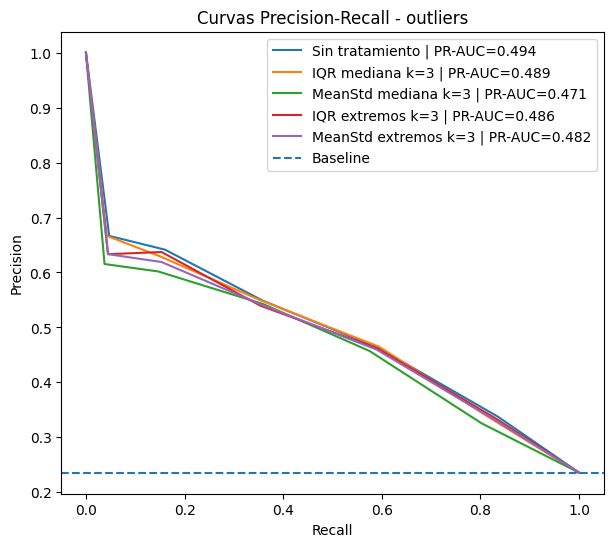


Probando bloque: imputer


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
2,IterativeImputer,0.497136,0.443926,0.445390,0.370283,0.558719,0.782778
0,Media,0.493990,0.441857,0.433666,0.358491,0.548736,0.779444
1,KNNImputer,0.486251,0.437080,0.439437,0.367925,0.545455,0.778889



Mejor opción para imputer: IterativeImputer
PR-AUC: 0.4971


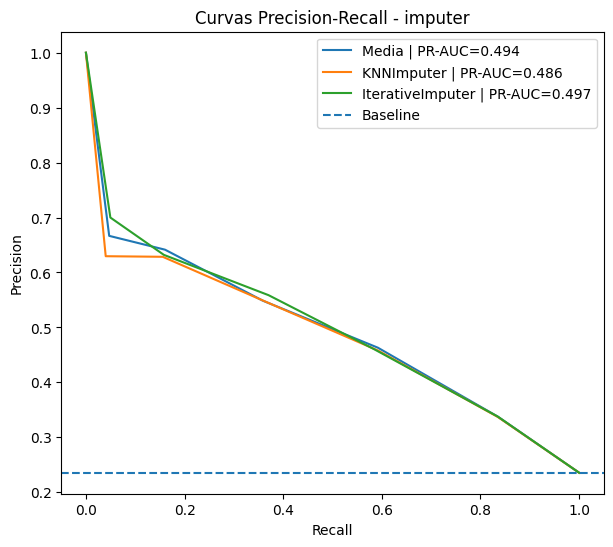


Probando bloque: new_features


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
1,Sí,0.501775,0.446167,0.442225,0.365566,0.559567,0.782778
0,No,0.497136,0.443926,0.445390,0.370283,0.558719,0.782778



Mejor opción para new_features: Sí
PR-AUC: 0.5018


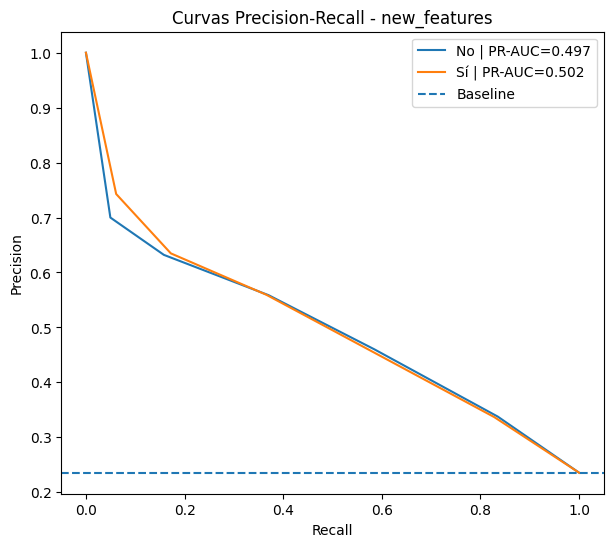


Probando bloque: log


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
0,No,0.501775,0.446167,0.442225,0.365566,0.559567,0.782778
1,Sí,0.494261,0.442398,0.424855,0.346698,0.548507,0.778889



Mejor opción para log: No
PR-AUC: 0.5018


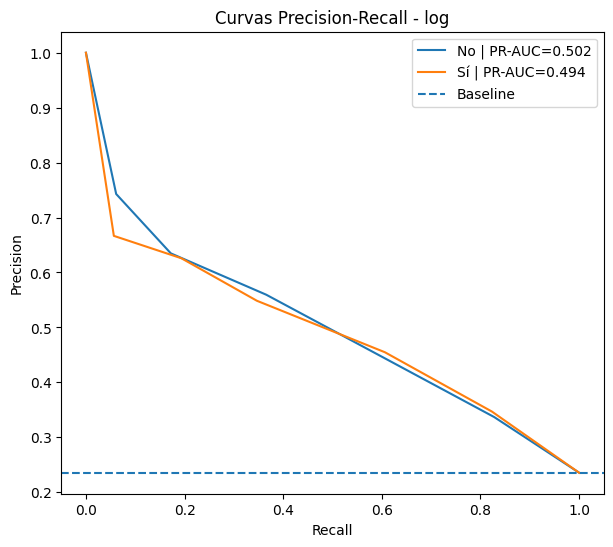


Probando bloque: corr_selector


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
2,Correlación umbral 0.8,0.505078,0.445002,0.427547,0.351415,0.545788,0.778333
0,No,0.501775,0.446167,0.442225,0.365566,0.559567,0.782778
1,Correlación umbral 0.9,0.495010,0.437331,0.416303,0.337264,0.543726,0.777222



Mejor opción para corr_selector: Correlación umbral 0.8
PR-AUC: 0.5051


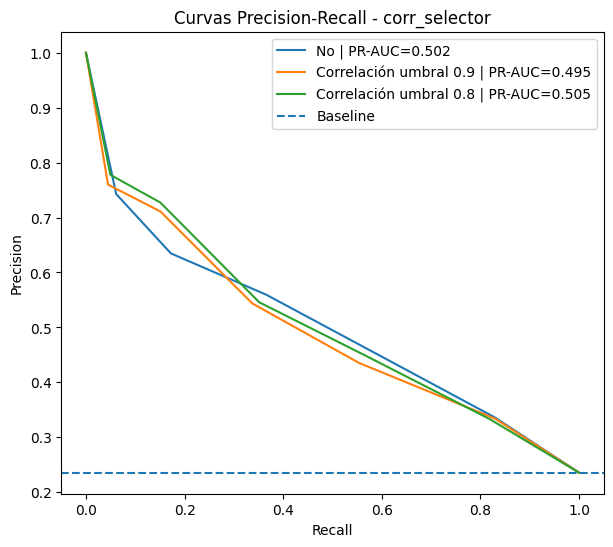


Probando bloque: scaler


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
0,StandardScaler,0.505078,0.445002,0.427547,0.351415,0.545788,0.778333
1,RobustScaler,0.489512,0.432755,0.423249,0.334906,0.574899,0.785000



Mejor opción para scaler: StandardScaler
PR-AUC: 0.5051


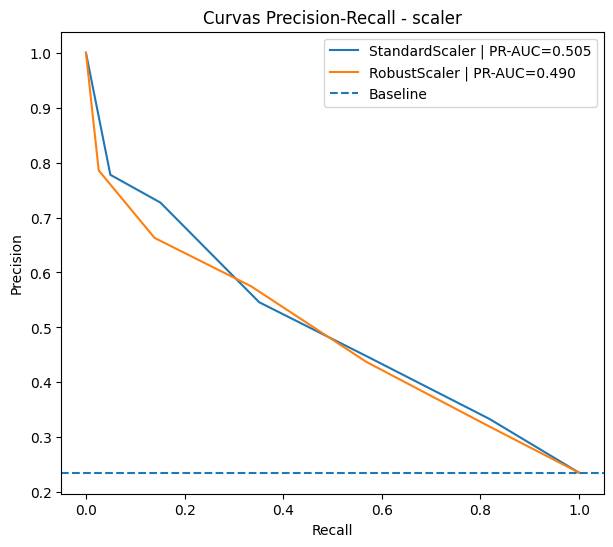


Probando bloque: selector


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
0,No,0.505078,0.445002,0.427547,0.351415,0.545788,0.778333
2,SelectKBest f_classif k=10,0.494768,0.442922,0.450899,0.384434,0.545151,0.779444
1,SelectKBest f_classif k=7,0.479958,0.435679,0.460705,0.400943,0.541401,0.778889



Mejor opción para selector: No
PR-AUC: 0.5051


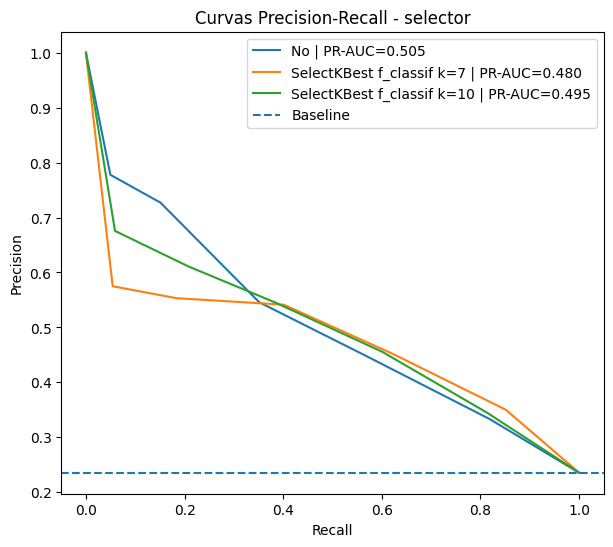

,Paso,Mejor opción,Mejor PR_AUC,Mejor F1,Mejor Recall,Mejor Precision
0,outliers,Sin tratamiento,0.493990,0.433666,0.358491,0.548736
1,imputer,IterativeImputer,0.497136,0.445390,0.370283,0.558719
2,new_features,Sí,0.501775,0.442225,0.365566,0.559567
3,log,No,0.501775,0.442225,0.365566,0.559567
4,corr_selector,Correlación umbral 0.8,0.505078,0.427547,0.351415,0.545788
5,scaler,StandardScaler,0.505078,0.427547,0.351415,0.545788
6,selector,No,0.505078,0.427547,0.351415,0.545788



CONFIGURACIÓN FINAL
outliers: Sin tratamiento
imputer: IterativeImputer
scaler: StandardScaler
new_features: Sí
log: No
corr_selector: Correlación umbral 0.8
selector: No

Rendimiento final en validación:
PR-AUC: 0.5051
Accuracy: 0.7783
Precision: 0.5458
Recall: 0.3514
F1: 0.4275


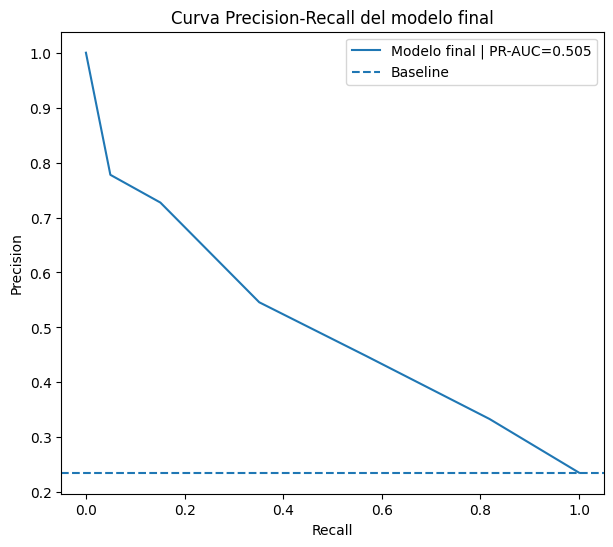

In [ ]:
from sklearn.metrics import (
    precision_recall_curve, auc, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


opciones = {
    "outliers": [
        ("Sin tratamiento", lambda: "passthrough"),
        ("IQR mediana k=3", lambda: OutlierDetecion_treatment_IQR(k=3)),
        ("MeanStd mediana k=3", lambda: OutlierDetecion_treatment_MeanStd(k=3)),
        ("IQR extremos k=3", lambda: OutlierDetecion_treatment_IQR_Extremos(k=3)),
        ("MeanStd extremos k=3", lambda: OutlierDetecion_treatment_MeanStd_Extremos(k=3)),
    ],

    "imputer": [
        ("Media", lambda: SimpleImputer(strategy="mean")),
        ("KNNImputer", lambda: KNNImputer(n_neighbors=5, weights="uniform")),
        ("IterativeImputer", lambda: IterativeImputer(max_iter=10, random_state=42)),
    ],

    "scaler": [
        ("StandardScaler", lambda: StandardScaler()),
        ("RobustScaler", lambda: RobustScaler()),
    ],

    "new_features": [
        ("No", lambda: "passthrough"),
        ("Sí", lambda: FeatureConstruction()),
    ],

    "log": [
        ("No", lambda: "passthrough"),
        ("Sí", lambda: LogTransformer()),
    ],

    "corr_selector": [
        ("No", lambda: "passthrough"),
        ("Correlación umbral 0.9", lambda: corr_selection(umbral=0.9)),
        ("Correlación umbral 0.8", lambda: corr_selection(umbral=0.8)),
    ],

    "selector": [
        ("No", lambda: "passthrough"),
        ("SelectKBest f_classif k=7", lambda: SelectKBest(score_func=f_classif, k=7)),
        ("SelectKBest f_classif k=10", lambda: SelectKBest(score_func=f_classif, k=10)),
    ],
}


config_actual = {
    "outliers": ("Sin tratamiento", lambda: "passthrough"),
    "imputer": ("Media", lambda: SimpleImputer(strategy="mean")),
    "scaler": ("StandardScaler", lambda: StandardScaler()),
    "new_features": ("No", lambda: "passthrough"),
    "log": ("No", lambda: "passthrough"),
    "corr_selector": ("No", lambda: "passthrough"),
    "selector": ("No", lambda: "passthrough"),
}


def crear_pipeline(config):
    num_pipeline = Pipeline(steps=[
        ("outliers", config["outliers"][1]()),
        ("imputer", config["imputer"][1]()),
        ("new_features", config["new_features"][1]()),
        ("log", config["log"][1]()),
        ("corr_selector", config["corr_selector"][1]()),
        ("scaler", config["scaler"][1]()),
    ])

    cat_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ])

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("selector", config["selector"][1]()),
        ("knn", KNeighborsClassifier())
    ])

    return pipeline



def evaluar_configuracion(config):
    modelo = crear_pipeline(config)
    modelo.fit(X_train, y_train)

    y_val_proba = modelo.predict_proba(X_val)[:, 1]
    y_val_pred = modelo.predict(X_val)

    precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_val_proba)
    pr_auc = auc(recall_curve, precision_curve)
    ap = average_precision_score(y_val, y_val_proba)

    return {
        "modelo": modelo,
        "precision_curve": precision_curve,
        "recall_curve": recall_curve,
        "PR_AUC": pr_auc,
        "Average_Precision": ap,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred, zero_division=0),
        "F1": f1_score(y_val, y_val_pred, zero_division=0),
    }




def probar_paso(nombre_paso, config_actual):
    resultados = []
    curvas = {}

    print(f"\n==============================")
    print(f"Probando bloque: {nombre_paso}")
    print(f"==============================")

    for nombre_opcion, factory in opciones[nombre_paso]:
        config_prueba = config_actual.copy()
        config_prueba[nombre_paso] = (nombre_opcion, factory)

        res = evaluar_configuracion(config_prueba)

        resultados.append({
            "Opción": nombre_opcion,
            "PR_AUC": res["PR_AUC"],
            "Average_Precision": res["Average_Precision"],
            "F1": res["F1"],
            "Recall": res["Recall"],
            "Precision": res["Precision"],
            "Accuracy": res["Accuracy"],
        })

        curvas[nombre_opcion] = (
            res["recall_curve"],
            res["precision_curve"],
            res["PR_AUC"]
        )

    tabla = pd.DataFrame(resultados).sort_values("PR_AUC", ascending=False)
    display(tabla)

    mejor_opcion = tabla.iloc[0]["Opción"]
    mejor_pr_auc = tabla.iloc[0]["PR_AUC"]

    print(f"\nMejor opción para {nombre_paso}: {mejor_opcion}")
    print(f"PR-AUC: {mejor_pr_auc:.4f}")

    # Graficar curvas PR del bloque probado
    plt.figure(figsize=(7, 6))

    for nombre_opcion, (recall_curve, precision_curve, pr_auc) in curvas.items():
        plt.plot(recall_curve, precision_curve, label=f"{nombre_opcion} | PR-AUC={pr_auc:.3f}")

    plt.axhline(y=y_val.mean(), linestyle="--", label="Baseline")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Curvas Precision-Recall - {nombre_paso}")
    plt.legend()
    plt.show()

    # Actualizar configuración con la mejor opción
    for nombre_opcion, factory in opciones[nombre_paso]:
        if nombre_opcion == mejor_opcion:
            config_actual[nombre_paso] = (nombre_opcion, factory)

    return config_actual, tabla



orden_pasos = [
    "outliers",
    "imputer",
    "new_features",
    "log",
    "corr_selector",
    "scaler",
    "selector"
]

historial = []

for paso in orden_pasos:
    config_actual, tabla_paso = probar_paso(paso, config_actual)

    historial.append({
        "Paso": paso,
        "Mejor opción": config_actual[paso][0],
        "Mejor PR_AUC": tabla_paso.iloc[0]["PR_AUC"],
        "Mejor F1": tabla_paso.iloc[0]["F1"],
        "Mejor Recall": tabla_paso.iloc[0]["Recall"],
        "Mejor Precision": tabla_paso.iloc[0]["Precision"],
    })


tabla_historial = pd.DataFrame(historial)
display(tabla_historial)




modelo_final = crear_pipeline(config_actual)
modelo_final.fit(X_train, y_train)

y_val_proba = modelo_final.predict_proba(X_val)[:, 1]
y_val_pred = modelo_final.predict(X_val)

precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_val_proba)
pr_auc_final = auc(recall_curve, precision_curve)

print("\n==============================")
print("CONFIGURACIÓN FINAL")
print("==============================")

for paso, valor in config_actual.items():
    print(f"{paso}: {valor[0]}")

print("\nRendimiento final en validación:")
print("PR-AUC:", round(pr_auc_final, 4))
print("Accuracy:", round(accuracy_score(y_val, y_val_pred), 4))
print("Precision:", round(precision_score(y_val, y_val_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_val, y_val_pred, zero_division=0), 4))
print("F1:", round(f1_score(y_val, y_val_pred, zero_division=0), 4))

plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve, label=f"Modelo final | PR-AUC={pr_auc_final:.3f}")
plt.axhline(y=y_val.mean(), linestyle="--", label="Baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall del modelo final")
plt.legend()
plt.show()

# Resultados del Grid Search

In [23]:
tabla = tabla_historial.copy()

tabla = tabla[[
    "Paso",
    "Mejor opción",
    "Mejor PR_AUC",
    "Mejor F1",
    "Mejor Recall",
    "Mejor Precision"
]]

tabla.columns = [
    "Paso",
    "Mejor opción",
    "PR-AUC",
    "F1",
    "Recall",
    "Precision"
]

tabla[["PR-AUC", "F1", "Recall", "Precision"]] = tabla[[
    "PR-AUC",
    "F1",
    "Recall",
    "Precision"
]].round(4)

tabla = tabla.reset_index(drop=True)

print(tabla.to_string())

            Paso            Mejor opción  PR-AUC      F1  Recall  Precision
0       outliers         Sin tratamiento  0.4940  0.4337  0.3585     0.5487
1        imputer        IterativeImputer  0.4971  0.4454  0.3703     0.5587
2   new_features                      Sí  0.5018  0.4422  0.3656     0.5596
3            log                      No  0.5018  0.4422  0.3656     0.5596
4  corr_selector  Correlación umbral 0.8  0.5051  0.4275  0.3514     0.5458
5         scaler          StandardScaler  0.5051  0.4275  0.3514     0.5458
6       selector                      No  0.5051  0.4275  0.3514     0.5458


# Param Grid Search en KNN

In [25]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, f1_score, recall_score, precision_score
from sklearn.neighbors import KNeighborsClassifier

pipeline_knn_ajustado = crear_pipeline(config_actual)

param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_knn = GridSearchCV(
    estimator=pipeline_knn_ajustado,
    param_grid=param_grid_knn,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_knn.fit(X_train, y_train)

print("Mejor PR-AUC en validación cruzada:", grid_knn.best_score_)
print("Mejores parámetros del KNN:")
print(grid_knn.best_params_)

best_model = grid_knn.best_estimator_

y_val_pred = best_model.predict(X_val)
y_val_proba = best_model.predict_proba(X_val)[:, 1]

print("\nMatriz de confusión en validación:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification report en validación:")
print(classification_report(y_val, y_val_pred))

print("PR-AUC:", average_precision_score(y_val, y_val_proba))
print("F1:", f1_score(y_val, y_val_pred, zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred, zero_division=0))
print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejor PR-AUC en validación cruzada: 0.5696404841928944
Mejores parámetros del KNN:
{'knn__metric': 'euclidean', 'knn__n_neighbors': 31, 'knn__weights': 'distance'}

Matriz de confusión en validación:
[[1315   61]
 [ 320  104]]

Classification report en validación:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      1376
           1       0.63      0.25      0.35       424

    accuracy                           0.79      1800
   macro avg       0.72      0.60      0.61      1800
weighted avg       0.76      0.79      0.75      1800

PR-AUC: 0.547088814679515
F1: 0.3531409168081494
Recall: 0.24528301886792453
Precision: 0.6303030303030303


## Métricas de rendimiento  
* Métricas dependientes del umbral: matriz de confusión

In [27]:
matriz_confusion = confusion_matrix(y_val, y_val_pred)

print("Matriz de confusión:")
print(matriz_confusion)
print()
print("Accuracy:", np.round(accuracy_score(y_val, y_val_pred) * 100, 2)) # habria que quitar
print("Precision:", np.round(precision_score(y_val, y_val_pred, pos_label=1) * 100, 2))
print("Recall:", np.round(recall_score(y_val, y_val_pred, pos_label=1) * 100, 2))
print("F1:", np.round(f1_score(y_val, y_val_pred, pos_label=1) * 100, 2))
print()
print(classification_report(y_val, y_val_pred))   

# antes de generacionvariables y log:
"""Matriz de confusión:
[[1283   93]
 [ 273  151]]

Accuracy: 79.67
Precision: 61.89
Recall: 35.61
F1: 45.21"""

Matriz de confusión:
[[1315   61]
 [ 320  104]]

Accuracy: 78.83
Precision: 63.03
Recall: 24.53
F1: 35.31

              precision    recall  f1-score   support

           0       0.80      0.96      0.87      1376
           1       0.63      0.25      0.35       424

    accuracy                           0.79      1800
   macro avg       0.72      0.60      0.61      1800
weighted avg       0.76      0.79      0.75      1800



'Matriz de confusión:\n[[1283   93]\n [ 273  151]]\n\nAccuracy: 79.67\nPrecision: 61.89\nRecall: 35.61\nF1: 45.21'

* Métricas independientes del umbral: curvas ROC y PR

In [28]:

precision_curve, recall_curve, umbrales_pr = precision_recall_curve(y_val, y_val_proba, pos_label=1)
pr_auc = auc(recall_curve, precision_curve)

print("PR-AUC:", pr_auc)

PR-AUC: 0.5449534957801572


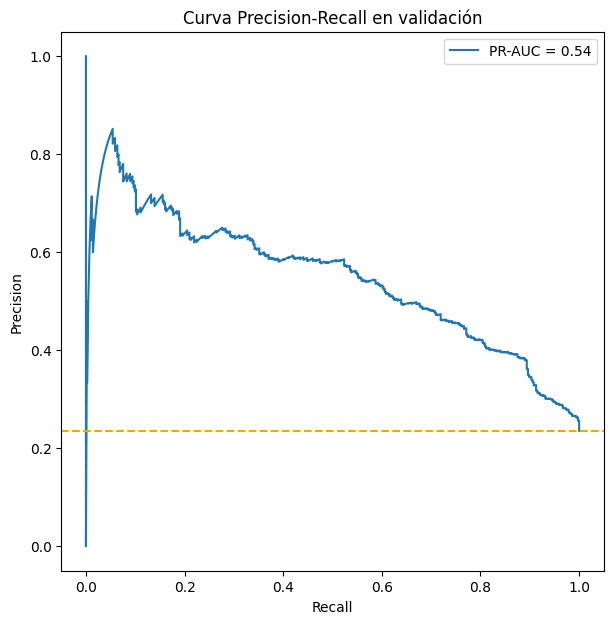

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,7))

ratio_positivos = y_val.mean()
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.2f}")
plt.axhline(y=y_val.mean(), linestyle="--", color="orange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall en validación")
plt.legend()

plt.show()

In [30]:
umbrales = np.arange(0.10, 1.00, 0.05)

resultados_umbral = []

for umbral in umbrales:
    y_val_umbral = (y_val_proba >= umbral).astype(int)
    acc = accuracy_score(y_val, y_val_umbral)
    prec = precision_score(y_val, y_val_umbral, pos_label=1)
    rec = recall_score(y_val, y_val_umbral, pos_label=1)
    f1 = f1_score(y_val, y_val_umbral, pos_label=1)
    resultados_umbral.append([umbral, acc, prec, rec, f1])

tabla_umbral = pd.DataFrame(resultados_umbral, columns=["umbral", "accuracy", "precision", "recall", "f1"])
tabla_umbral

c:\Users\alano\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alano\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alano\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

,umbral,accuracy,precision,recall,f1
0,0.10,0.529444,0.323308,0.912736,0.477483
1,0.15,0.627222,0.377114,0.893868,0.530441
2,0.20,0.707222,0.431968,0.771226,0.553768
3,0.25,0.750556,0.480000,0.707547,0.571973
4,0.30,0.782778,0.535484,0.587264,0.560180
5,0.35,0.797222,0.576623,0.523585,0.548826
6,0.40,0.792778,0.587031,0.405660,0.479777
7,0.45,0.795556,0.620690,0.339623,0.439024
8,0.50,0.788333,0.630303,0.245283,0.353141
9,0.55,0.787222,0.669421,0.191038,0.297248


In [31]:
mejor_f1 = tabla_umbral.loc[tabla_umbral["f1"].idxmax()]
umbral_optimo = np.round(mejor_f1["umbral"], 2)

print("Mejor fila según F1:")
print(mejor_f1)
print()
print("Umbral óptimo:", umbral_optimo)

"""Mejor fila según F1:  # antes de generacion vars y log
umbral       0.200000
accuracy     0.713889
precision    0.437068
recall       0.745283
f1           0.551003
Name: 2, dtype: float64

Umbral óptimo: 0.2"""

Mejor fila según F1:
umbral       0.250000
accuracy     0.750556
precision    0.480000
recall       0.707547
f1           0.571973
Name: 3, dtype: float64

Umbral óptimo: 0.25


'Mejor fila según F1:  # antes de generacion vars y log\numbral       0.200000\naccuracy     0.713889\nprecision    0.437068\nrecall       0.745283\nf1           0.551003\nName: 2, dtype: float64\n\nUmbral óptimo: 0.2'

# Rendimiento en test

In [32]:
y_test_proba = best_model.predict_proba(X_test)[:,1]
y_test_pred = (y_test_proba >= umbral_optimo).astype(int)

matriz_confusion_test = confusion_matrix(y_test,y_test_pred)

print("Matriz de confusión en test:")
print(matriz_confusion_test)
print()
print("Accuracy:", np.round(accuracy_score(y_test, y_test_pred) * 100, 2))
print("Precision:", np.round(precision_score(y_test, y_test_pred) * 100, 2))
print("Recall:", np.round(recall_score(y_test, y_test_pred) * 100, 2))
print("F1:", np.round(f1_score(y_test, y_test_pred) * 100, 2))

precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba, pos_label=1)
pr_auc_test = np.round(auc(recall_test, precision_test)* 100, 2)
print("PR-AUC:", pr_auc_test)

Matriz de confusión en test:
[[551 214]
 [ 80 155]]

Accuracy: 70.6
Precision: 42.01
Recall: 65.96
F1: 51.32
PR-AUC: 49.71


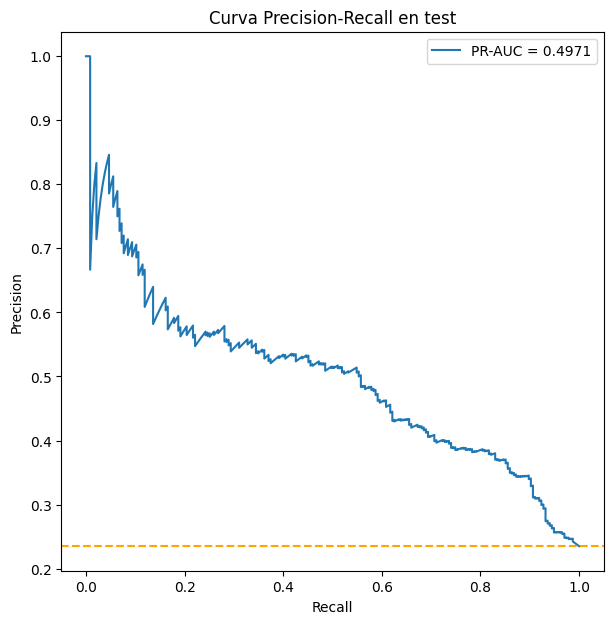

In [33]:
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba, pos_label=1)

plt.figure(figsize=(7,7))

ratio_positivos = y_test.mean()
plt.plot(recall_test, precision_test, label=f"PR-AUC = {auc(recall_test, precision_test):.4f}")
plt.axhline(y=y_test.mean(), linestyle="--", color="orange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall en test")
plt.legend()

plt.show()

Objetivo:  
evitar dropouts, evitar alumno que va a abandonar y no detectar (falso negativo)  
Maximizar recall, f1, pr